# 実行例6.2 ETL1手書き数字データの判別分析2値化法（p.84図6.7）

### 0.  フィッシャーの基準 $J(w)$ とクラス分離評価関数 $h$

1. フィッシャーの基準と線形判別
- フィッシャーの基準 : 評価関数（クラスが等確率）
$$
J(w) = \frac{(m_1 - m_2)^2}{S_1^2 + S_2^2}
$$
- フィッシャーの線形判別 : 多次元データに対して $J$ を最大化する射影方向 $w$ を求めること
  - 最適解は $w^* = S_W^{-1} * (m_1 - m_2)$

2. クラス分離の評価関数
- クラス分離の評価関数を $h(m_1, \sigma_1^2, m_2, \sigma_2^2)$ とする。
$$
h = \frac{クラス間分散}{クラス内分散} 
= \frac{P(C_1)(m_1 - \bar{m})^2 + P(C_2)(m_2 - \bar{m})^2}{P(C_1)\sigma_1^2 + P(C_2)\sigma_2^2} 
$$
  - 分子 = クラス間分散 $\sigma^2_B$（各クラスの重心が全体平均からどれだけ離れているか）
  - 分母 = クラス内分散 $\sigma^2_W$（各クラス内のばらつきの加重平均）
  - $\bar{m} = P(C_1) * m_1 + P(C_2) * m_2$（全体の加重平均）

3. 判別分析2値化法（ETL1への適用）
- クラス間分散 $\sigma_B^2$ とクラス内分散 $\sigma_W^2$ に対して、フィッシャーの基準 $h = \sigma^2_B / \sigma^2_W$ を閾値探索に直接適用する。
- 明るさのヒストグラムはすでに1次元なので、射影方向を探す必要がない。
- $\sigma_T^2 = \sigma_W^2 +\sigma_B^2$ とすると
$$
h = \frac{\sigma_B^2}{\sigma_W^2} =  \frac{1}{\sigma_T^2 / \sigma_B^2 - 1}
$$
- $\sigma_T^2$ はデータが決まると一定値を取るので $\sigma_B^2$ が最大となる境界を見つける。
- 閾値を1つずつ動かして $h$ が最大になる明るさレベルを選ぶ。
- 「フィッシャーの基準を使うが、線形判別（射影探し）、即ち $w$ 探索はしない」という位置づけ

- パッケージのインポートと関数類は`5.2.1_etl1-kNN.ipynb`を流用

In [1]:
using Pkg
Pkg.activate(@__DIR__)
using Statistics
using LinearAlgebra
using DataFrames
using CairoMakie
using Images
using Colors
using ImageView
using StringEncodings
using ImageFiltering
using ImageTransformations
using Interpolations
using StatsBase
using CUDA
using Random

#Axisの衝突回避
import CairoMakie: Axis  # Main の Axis = CairoMakie.Axis に固定


  Activating project at `c:\Users\salt_\OneDrive\Documents\!勉強\Julia\Pattern_recognition`


### 1. ETL1データの読み込みと明るさのヒストグラム作成

#### 1.1 ETL1画像（数字データ）の読み込み
- 今回は1つのデータだけあればいいがkNN法に合わせて数字データを全て取り込んでおく。
- `5.2.1_etl1-kNN.ipynb`では`raw_image`を切り抜いて`test_image`にしていたため、今回は`raw_data`しか使用しないが保守性維持のため切り抜き、フィルター、リサイズの関数もそのまま取り込んでおく。

##### 1.1.1 切り抜き関数

In [2]:
# 閾値調整
threshold_mat = 96

# (2)オリジナル状態での手書き部分の切り抜き（正方形）
function img_cutting_mat(mat::Matrix{Int})
    # ①手書き位置の確認
    # 一番端のピクセル位置の初期化
    p_top, p_bottom, p_left, p_right = 63, 1, 64, 1
    # 手書き文字と認識する閾値の設定
    p_threshold = threshold_mat
    # 一番端のピクセル位置の探索
    for i in 1:63
        for j in 1:64
            if mat[i, j] > p_threshold
                if i < p_top
                    p_top = i
                end
                if i > p_bottom
                    p_bottom = i
                end
                
                if j < p_left
                    p_left = j
                end
                if j > p_right
                    p_right = j
                end
            end
        end
    end
    # 【テスト】上下左右の端の位置の確認
    # println(p_top, ":", p_bottom, ":", p_left, ":", p_right)

    # ②切り抜きサイズの確認
    # 上下と左右の幅の広さを比較
    # 文字の書かれている箇所を正方形で切り抜くための辺の長さの確認
    square_cut = 0
    # 文字の位置ずれを補正
    shift_width, shift_hight = 0, 0
    if (p_bottom - p_top) > (p_right - p_left)
        square_cut = p_bottom - p_top
        shift_width = ((p_bottom - p_top) - (p_right - p_left)) ÷ 2
    else
        square_cut = p_right - p_left
        shift_hight = ((p_right - p_left) - (p_bottom - p_top)) ÷ 2
    end

    # ③切り抜くにあたって長さが足りないところを黒いピクセルで埋めておく
    # 元の画像サイズ
    h, w = size(mat)  # 63, 64
    # 長手方向の長さ
    height = p_bottom - p_top
    width = p_right - p_left
    square = max(height, width)
    # 必要なパディング量
    pad_bottom = max(0, p_top + square - h)
    pad_right  = max(0, p_left + square - w)
    # 黒ピクセルでパディング
    new_h = h + pad_bottom
    new_w = w + pad_right
    padded = fill(Int(0), new_h, new_w)   # オリジナル状態でパディング
    padded[1:h, 1:w] = mat

    # ④正方形に切り抜き
    # cutting_mat = padded[p_top - shift_hight:p_top + square_cut, p_left - shift_width : p_left + square_cut]
    row_start = max(1, p_top - shift_hight)
    row_end   = min(new_h, row_start + square_cut)
    col_start = max(1, p_left - shift_width)
    col_end   = min(new_w, col_start + square_cut)
    cutting_mat = padded[row_start:row_end, col_start:col_end]

    return cutting_mat, square    # 切り抜き結果の画像、画像の辺の長さ
end

img_cutting_mat (generic function with 1 method)

##### 1.1.2 フィルター関数

In [3]:
# (1) ガウシアンフィルター
# ガウシアンカーネル
function gaussian_kernel(size, sigma)
    k = zeros(size, size)
    c = size ÷ 2 + 1
    for i in 1:size
        for j in 1:size
            x = i - c
            y = j - c
            k[i, j] = exp(-(x^2 + y^2) / (2 * sigma^2))
        end
    end
    k ./= sum(k)
    return k
end

# ガウシアンフィルター
function gaussian_filter(img, kernel_size=5, sigma=1.0)
    k = gaussian_kernel(kernel_size, sigma)
    return imfilter(img, k)
end

gaussian_filter (generic function with 3 methods)

##### 1.1.3 リサイズ関数

In [4]:
# (1) リサイズ
function img_resize(mat, alg=1)
    #=
    mat⇒
    alg⇒
        1:Bicubic
        2:Bilinear
        3:Nearest neighbor
    =#
    
    if alg == 1
        resized_image = imresize(mat, (16, 16), method=BSpline(Cubic(Line(OnGrid()))))
    elseif alg == 2
        resized_image = imresize(mat, (16, 16), method=BSpline(Linear()))
    elseif alg == 3
        resized_image = imresize(mat, (16, 16), method=BSpline(Constant()))
    else
        resized_image = mat
    end

    return resized_image
end

img_resize (generic function with 2 methods)

##### 1.1.4 数字データの取り込み

In [5]:
# (1)データの定義
struct ETL1normalNN
    data_number::Int
    char_code::Int
    writer_id::Int
    raw_image::Matrix{Int}
    test_image::Matrix{Int}
end

# (2)ファイルパスの指定
file_01 = joinpath(@__DIR__, "ETL1C_01")
file_02 = joinpath(@__DIR__, "ETL1C_02")

# (3)ファイルの読み込み関数
function read_and_strange(filepath)
    records_normalNN = ETL1normalNN[]
    record_size = 2052
    
    open(filepath, "r") do io
        while !eof(io)
            data = read(io, record_size)
            length(data) < record_size && break
            
            # Metadata
            data_number = ntoh(reinterpret(UInt16, data[1:2])[1])
            char_code   = ntoh(reinterpret(UInt16, data[3:4])[1])
            writer_id   = ntoh(reinterpret(UInt16, data[5:6])[1])
            
            # Image data(raw_image)
            image_data = data[33:2048]
            pixels = Int[]
            for byte in image_data
                push!(pixels, (byte >> 4) * 17)
                push!(pixels, (byte & 0x0F) * 17)
            end
            raw_image = transpose(reshape(pixels[1:64*63], 64, 63))

            # Image data(test_image)
            # 切り抜きと位置ズレの補正
            temp_img = img_cutting_mat(Matrix(raw_image))[1]            
            # 画像サイズが十分な場合にフィルターでアンチエリアシング後リサイズ
            # if size(temp_img, 1) == 0
            if size(temp_img, 1) < 5 || size(temp_img, 2) < 5
                temp_img = zeros(Int, 16, 16)
            else
                temp_img = gaussian_filter(temp_img, 5, 10)
                temp_img  = img_resize(temp_img, 1) # 1:Bicubic
            end
            test_image = Int.(round.(clamp.(temp_img, 0, 255)))

            push!(records_normalNN, ETL1normalNN(
                data_number,
                char_code,
                writer_id,
                raw_image,
                test_image
            ))
        end
    end

    return records_normalNN
end

# (3)ファイルの読み込み
records_normalNN = read_and_strange(file_01)
append!(records_normalNN, read_and_strange(file_02))

# (4)アルファベットデータを除いた数字だけのデータを抽出
records_digits = filter(r -> 0x3020 <= r.char_code <= 0x3920, records_normalNN) # Vector{ETL1normalNN}

14450-element Vector{ETL1normalNN}:
 ETL1normalNN(1, 12320, 1001, [34 17 … 17 17; 17 17 … 34 17; … ; 17 17 … 17 17; 17 17 … 17 17], [18 17 … 20 22; 16 17 … 21 23; … ; 17 26 … 20 19; 15 17 … 19 18])
 ETL1normalNN(2, 12320, 1002, [17 0 … 17 17; 17 17 … 17 17; … ; 17 17 … 17 17; 17 17 … 17 0], [14 10 … 16 16; 12 14 … 15 15; … ; 17 15 … 12 9; 21 16 … 9 11])
 ETL1normalNN(3, 12320, 1003, [34 17 … 17 17; 17 17 … 17 17; … ; 17 17 … 17 17; 17 34 … 17 17], [17 16 … 18 17; 17 16 … 17 17; … ; 16 18 … 18 19; 15 16 … 17 17])
 ETL1normalNN(4, 12320, 1004, [17 17 … 17 17; 17 17 … 17 17; … ; 17 17 … 17 17; 17 17 … 17 17], [16 17 … 16 15; 13 15 … 17 16; … ; 14 14 … 13 12; 12 12 … 14 13])
 ETL1normalNN(5, 12320, 1005, [34 17 … 17 17; 17 17 … 17 17; … ; 17 17 … 17 17; 17 34 … 17 17], [12 13 … 15 16; 15 15 … 15 16; … ; 19 45 … 17 15; 16 23 … 17 15])
 ETL1normalNN(6, 12320, 1006, [17 17 … 17 17; 17 17 … 34 17; … ; 17 17 … 17 0; 34 17 … 17 17], [13 10 … 26 24; 15 13 … 32 22; … ; 25 47 … 14 16; 19 33 … 13 16

#### 1.2 基本処理用の関数

In [18]:
# (1)Matrix{UInt8}をグレースケールに変換
function matrix_to_grayscale(img)
    gray_img = Gray{N0f8}.(img ./ 255)
    return gray_img
end

# (2)IntをASCII/ASCIIをIntに変換
function int_to_ascii(n)
    ascii = Int((0x30 + n) << 8 | 0x20)
    return ascii
end

function ascii_to_int(ascii::Int)
    return Int((ascii >> 8) - 0x30)
end

ascii_to_int (generic function with 2 methods)

#### 1.3 サンプルデータの抽出と`raw_data`描画
- `MersenneTwister()`を使う場合は`using Random`が必要

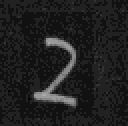

In [19]:
# (1)ランダムにサンプル抽出
# 乱数生成器作成
random_seed = 42
rng = MersenneTwister(random_seed)

# サンプル抽出
record_sample = rand(rng, records_digits)

# (2)抽出したサンプルの画像を表示
sample_image = matrix_to_grayscale(record_sample.raw_image)
save("xoutput.png", sample_image)
display(sample_image)

#### 1.2 明るさのヒストグラム作成
- `coutmap()` : `Matrix`の度数分布を`Dict`形式で取得（`using StatsBase`が必要）
- 明るさの階調は16レベル
- ただし元のデータは4ビット（16階調）の値を8ビットのデータ（0～255）に詰め込んだ結果、数値上は17（16進数で 0x11）ずつ増える形になっているものと思われる。
- 16刻みでない理由 : 画像処理やハードウェアの設計では「0 を含む 16 段階（0～15）」を「0～255（8ビットの全範囲）」にマッピングするという要件がよくある。この時、以下の式が使われる。ここで、$255 \div 15 = 17$ になる。
$$
MappedValue = floor \left(Input \times \frac{255}{15} \right)
$$
- `Images.jl`は内部で`AxisArrays.jl`を使っており、配列の次元に名前をつけるための`Axis`型をエクスポートしているため、`Axis`だけだと`CairoMakie.jl`と衝突を起こす。以下で`Main`に`Axis`を固定。
```julia
using CairoMakie
using Images
import CairoMakie: Axis  # これで Main の Axis = CairoMakie.Axis に固定
```

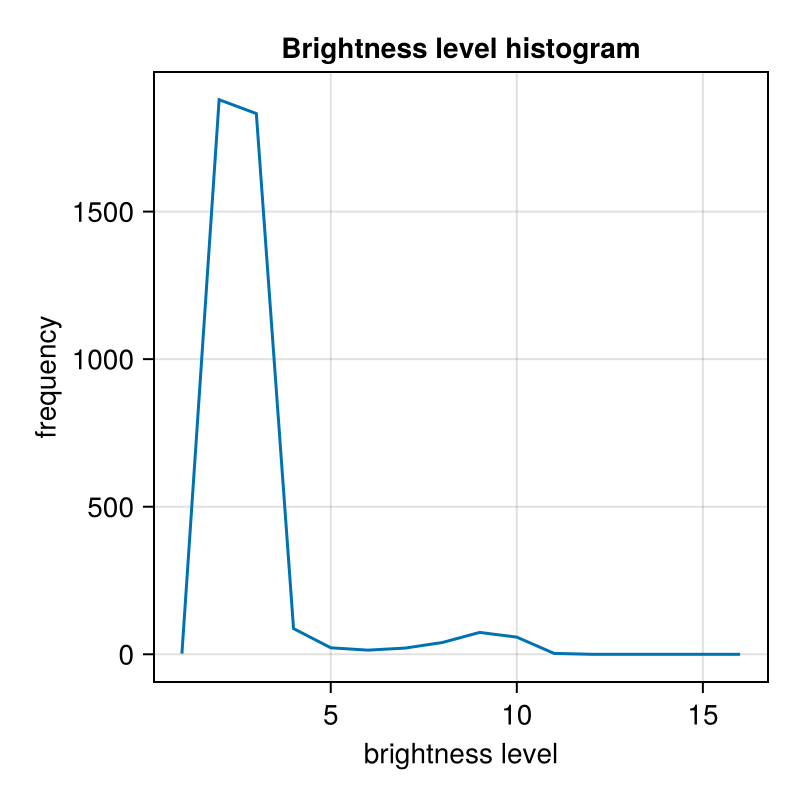

In [24]:
# (1)明るさの度数分布を取得する
# 辞書で取得
brightness_dict = countmap(record_sample.raw_image)
# 描画用の配列に置き換える
brightness_frequency = [get(brightness_dict, Int(i * 0x11), 0) for i in 0:15]

# (2)ヒストグラム描画
# 明るさの階調（16レベル）
brightness_range = range(1, 16, length=16)

# 描画
fig = Figure(size = (400, 400))
ax = Axis(fig[1, 1],
title="Brightness level histogram",
xlabel="brightness level",
ylabel="frequency")
lines!(ax, brightness_range, brightness_frequency)
save("xoutput.png", fig)
fig


##### 【debug】raw_imageのデータ内容

In [25]:
# 1. 辞書のキーを取得して、昇順にソートする
sorted_keys = sort(collect(keys(brightness_dict)))

# 2. そのソート済みのキーを使って、対応する値（頻度）を順番に取り出す
brightness_frequency = [brightness_dict[k] for k in sorted_keys]

# 3. 確認用：キーと頻度をセットで見る
println(typeof(sorted_keys))
println("Keys: ", sorted_keys)
println("Keys: ", (sorted_keys ./ 17))
println("Values: ", brightness_frequency)

Vector{Int64}
Keys: [0, 17, 34, 51, 68, 85, 102, 119, 136, 153, 170]
Keys: [0.0, 1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0, 10.0]
Values: [2, 1879, 1832, 87, 22, 14, 21, 40, 74, 58, 3]


##### 【debug】Axisの由来

In [26]:
for pkg in [Statistics, LinearAlgebra, DataFrames, CairoMakie, 
            Images, Colors, ImageView, StringEncodings, 
            ImageFiltering, ImageTransformations, Interpolations, 
            StatsBase, CUDA]
    if :Axis in names(pkg)
        println(pkg, " が Axis をエクスポートしている")
    end
end


CairoMakie が Axis をエクスポートしている
Images が Axis をエクスポートしている


### 2. クラス分離評価関数 $h$ の最大化

#### 2.1 全分散 $\sigma_T^2$ 、クラス間分散 $\sigma_B^2$ およびクラス内分散 $\sigma_W^2$ 計算関数
- クラス間分散
$$
\sigma_B^2 = P(C_1)(m_1 - \bar{m})^2 + P(C_2)(m_2 - \bar{m})^2
$$
- クラス内分散
$$
\sigma_W^2 = P(C_1) \sigma_1^2 + P(C_2) \sigma_2^2
$$
- クラス間分散、クラス内分散は境界の明るさレベル`brt_lv`で区分して計算
- `vec(M)`は`Matrix`を列優先で`Vector`に変形する。

In [32]:
# (1)全分散
function total_var(A)
    σ_T2 = var(A)
    return σ_T2
end

# (2)クラス分け
function class_sort(records::ETL1normalNN, brt_lv::Int)
    # recordsのraw_imageを明るさ（Int）の配列に変換
    brt_array = vec([Int(x / 0x11) for x in record_sample.raw_image])
    # 明るさbrt_lvでbrightとdarkに2分割
    brights = [x for x in brt_array if x >= brt_lv]
    darks = [x for x in brt_array if x < brt_lv]
    # 各クラスの事前確率
    P_brights = length(brights) / length(records)
    P_darks = length(darks) / length(records)
    return brights, darks, P_brights, P_darks
end

# (3)クラス間分散
function between_class_var(x_1, x_2, PC_1, PC_2)
    # クラスごとおよび全体の平均
    m_1 = mean(x_1)
    m_2 = mean(x_2)
    m_bar = mean([x_1 x_2])
    # クラス間分散
    σ_B2 = PC_1 * (m_1 - m_bar)^2 + PC_2 * (m_2 - m_bar)^2
    return σ_B2
end

# (4)クラス内分散
function within_class_var(x_1, x_2, PC_1, PC_2)
    # クラスごとの分散
    σ_1 = var(x_1)
    σ_2 = var(x_2)
    # クラス内分散
    σ_W2 = P_1 * σ_1 + P_2 * σ_2
    return σ_W2
end

within_class_var (generic function with 1 method)

In [30]:
class_sort(record_sample, 6)

([6, 9, 8, 8, 9, 9, 7, 8, 9, 9  …  6, 7, 8, 8, 7, 6, 6, 7, 7, 6], [2, 2, 1, 1, 2, 2, 2, 2, 2, 1  …  1, 2, 2, 1, 1, 2, 1, 1, 2, 2])

#### 2.2 全分散 $\sigma_T^2$ の計算

#### 2.3 明るさの境界レベルを変化させた時の  $\sigma_b^2$  の最大値による閾値決定

#### 2.4 計算した閾値による画像の2値化